## Environment Setup & BigQuery Configuration
We load the GOOGLE_PROJECT_ID from your .env file to establish a secure connection using the BigQuery Python SDK.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
from dotenv import load_dotenv
from google.cloud import bigquery

warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load environment variables
load_dotenv()
PROJECT_ID = os.getenv('GOOGLE_PROJECT_ID')

# Initialize BigQuery client (using OAuth)
client = bigquery.Client(project=PROJECT_ID)
DATASET = "olist"

print(f"Connected to project: {PROJECT_ID}, dataset: {DATASET}")

Connected to project: zwxpjt1, dataset: olist


## Data Loading & Initial Shape Analysis
We fetch the critical tables into DataFrames to begin the EDA process.

In [14]:
# =============================================================================
# 1. DATA LOADING AND INITIAL EXPLORATION
# =============================================================================

def load_table(table_name):
    query = f"SELECT * FROM `{PROJECT_ID}.{DATASET}.{table_name}`"
    return client.query(query).to_dataframe()

# Loading core tables
df_dim_customers = load_table('dim_customers')
df_dim_products = load_table('dim_products')
df_fct_sales = load_table('fct_sales')
df_int_orders_enriched = load_table('int_orders_enriched')
df_int_metrics = load_table('int_customer_metrics')
df_int_items_aggr = load_table('int_order_items_aggregated')

# Print shapes for initial audit
tables = {
    "dim_customers": df_dim_customers,
    "dim_products": df_dim_products,
    "fct_sales": df_fct_sales,
    "int_orders_enriched": df_int_orders_enriched,
    "int_metrics": df_int_metrics,
    "int_items_aggr": df_int_items_aggr
}

for name, df in tables.items():
    print(f"Table: {name:20} | Rows: {df.shape[0]:<7} | Columns: {df.shape[1]}")


Table: dim_customers        | Rows: 96096   | Columns: 15
Table: dim_products         | Rows: 32951   | Columns: 12
Table: fct_sales            | Rows: 113419  | Columns: 12
Table: int_orders_enriched  | Rows: 99441   | Columns: 29
Table: int_metrics          | Rows: 94698   | Columns: 4
Table: int_items_aggr       | Rows: 98666   | Columns: 4


## Statistical Profiling & Distribution Curves
Using .describe() to identify numerical anomalies and long-tail distributions in sales metrics.

--- FCT_SALES Metrics ---


,price,freight_value,total_payment_value
count,113419.000000,113419.000000,113419.000000
mean,121.268048,19.854707,141.148161
std,185.555920,15.838002,191.917384
min,0.850000,0.000000,9.340000
25%,39.900000,12.960000,55.790000
50%,75.000000,16.220000,92.650000
75%,135.000000,21.150000,158.100000
max,6735.000000,409.680000,6929.310000


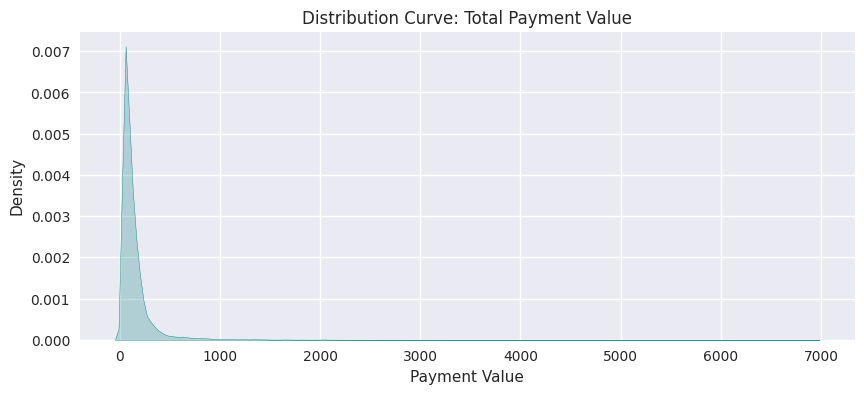

In [15]:
# =============================================================================
# 2. STATISTICAL PROFILING
# =============================================================================

# --- FIX: Convert to Float for math/plotting ---
cols_to_fix = ['price', 'freight_value', 'total_payment_value']
df_fct_sales[cols_to_fix] = df_fct_sales[cols_to_fix].astype(float)

print("--- FCT_SALES Metrics ---")
# Now this will show Mean, Std, Min, Max instead of 'Unique/Top'
display(df_fct_sales[cols_to_fix].describe())

# Visualizing the curve for Sales Value
plt.figure(figsize=(10, 4))
sns.kdeplot(df_fct_sales['total_payment_value'], fill=True, color='teal')
plt.title('Distribution Curve: Total Payment Value')
plt.xlabel('Payment Value')
plt.show()


## Dim_Customers Logic Check & Order Status Filtering
Filtering out 'canceled' or 'unavailable' orders from the enriched table to explain null RFV scores in the customer dimension.

In [16]:
# =============================================================================
# 3. CUSTOMER DIMENSION & ENRICHED STATUS CHECK
# =============================================================================

# Filter orders to exclude canceled/unavailable
valid_orders = df_int_orders_enriched[~df_int_orders_enriched['order_status'].isin(['canceled', 'unavailable'])]

# Checking the null RFV records mentioned (e.g., 01012, 01019)
invalid_customers = df_dim_customers[df_dim_customers['rfv_score'].isna()]
print(f"Customers with NULL RFV: {len(invalid_customers)}")

# Verify customer_id_is_invalid is always False
print(f"Unique values in customer_id_is_invalid: {df_dim_customers['customer_id_is_invalid'].unique()}")


Customers with NULL RFV: 0
Unique values in customer_id_is_invalid: <BooleanArray>
[False]
Length: 1, dtype: boolean


## Dim_Products & Categorization Audit
Checking for 'uncategorized' placeholders and null values in physical dimensions.

In [17]:
# =============================================================================
# 4. PRODUCT VALIDATION & CATEGORY RETEST
# =============================================================================

# Retest uncategoried products
uncategorized = df_dim_products[df_dim_products['product_category_name'].isin(['', 'uncategorized'])]
print(f"Uncategorized Products count: {len(uncategorized)}")

# Checking for null weights/dimensions
null_specs = df_dim_products[['product_weight_g', 'product_length_cm']].isna().sum()
print("Missing Product Specifications:\n", null_specs)


Uncategorized Products count: 993
Missing Product Specifications:
 product_weight_g     0
product_length_cm    0
dtype: int64


## Intermediate Table Patching & Monetary Logic
Implementing logic to fill monetary_value from order_payments when order item data is missing.

In [18]:
# =============================================================================
# 5. METRICS & MONETARY VALUE CORRECTION
# =============================================================================

# --- Fix 1: Monetary Value (df_int_metrics) ---
# We convert to float first just in case, then fill nulls with 0
df_int_metrics['monetary_value'] = df_int_metrics['monetary_value'].astype(float).fillna(0)

# Verify the fix
null_monetary = df_int_metrics['monetary_value'].isna().sum()
print(f"5. Null Monetary Values remaining: {null_monetary} (Expected: 0)")


# --- Fix 2: Rounding (df_int_items_aggr) ---
df_int_items_aggr = load_table('int_order_items_aggregated')

# We MUST convert to float before rounding to avoid the "Object" error
df_int_items_aggr['total_item_value'] = df_int_items_aggr['total_item_value'].astype(float).round(2)
df_int_items_aggr['total_freight_value'] = df_int_items_aggr['total_freight_value'].astype(float).round(2)

print("Rounded long decimals for Item Aggregation table.")
display(df_int_items_aggr.tail(1))


5. Null Monetary Values remaining: 0 (Expected: 0)
Rounded long decimals for Item Aggregation table.


,order_id,total_item_value,total_freight_value,total_items
98665,b4546ff451b39382f5c1dd81355a0c58,238.99,22.47,1


## City & State Normalization Check
Verifying that all geographic data is standardized by ensuring no accents remain in city or state names.

In [19]:
# =============================================================================
# 6. ACCENT & NORMALIZATION AUDIT
# =============================================================================

import re

def has_accents(text):
    if text is None: return False
    # Checks for characters outside standard A-Z, 0-9, and basic punctuation
    return bool(re.search(r'[^\x00-\x7F]+', str(text)))

# 1. Check Cities
accented_cities = df_dim_customers[df_dim_customers['customer_city'].apply(has_accents)]

# 2. Check States
accented_states = df_dim_customers[df_dim_customers['customer_state'].apply(has_accents)]

print(f"--- Accent Check Results ---")
print(f"Cities with remaining accents: {len(accented_cities)}")
print(f"States with remaining accents: {len(accented_states)}")

if len(accented_cities) > 0:
    print("\nSample of accented cities found:")
    display(accented_cities[['customer_id', 'customer_city']].head(5))
else:
    print("\n✅ All cities are successfully normalized (Accents removed).")

# Show the 10 problematic cities
display(accented_cities[['customer_id', 'customer_city', 'customer_state']])


--- Accent Check Results ---
Cities with remaining accents: 10
States with remaining accents: 0

Sample of accented cities found:


,customer_id,customer_city
70235,af8d07e04415b17eec6472d8f31e83ed,maceia³
70236,99a6c03de00a86b302d05d0eedd6e0e0,maceia³
70237,bfdb1f4f667634b7ff30a716e6fafa95,maceia³
70238,79014ee04085d90c94cb55b6042e4bb7,maceia³
70239,ebf83d791ff75483ab26bc06ab002e32,maceia³


,customer_id,customer_city,customer_state
70235,af8d07e04415b17eec6472d8f31e83ed,maceia³,AL
70236,99a6c03de00a86b302d05d0eedd6e0e0,maceia³,AL
70237,bfdb1f4f667634b7ff30a716e6fafa95,maceia³,AL
70238,79014ee04085d90c94cb55b6042e4bb7,maceia³,AL
70239,ebf83d791ff75483ab26bc06ab002e32,maceia³,AL
70240,bf82837a50afe7e09679eeedfa1285ce,maceia³,AL
70241,0d3670b39e22cd5272b0cee0bcbfd600,maceia³,AL
70242,2c8deb31537465309060d5176e5da3d3,maceia³,AL
70243,55358388564c39b1d171621395ea2544,maceia³,AL
70244,41cdb26d1a0145f92b2fa8ea92b9cd0b,maceia³,AL


## Final Sales & Payments Integrity
Removing records where payment methods or total payments are zero to ensure fct_sales purity.

In [20]:
# =============================================================================
# 7. FINAL INTEGRITY CHECKS (FCT_SALES)
# =============================================================================

df_payments_summary = load_table('int_order_payments_summary')

# Identify zero-payment orders to remove from Fact table
invalid_payment_ids = df_payments_summary[
    (df_payments_summary['unique_payment_methods'] == 0) | 
    (df_payments_summary['total_order_payment'] == 0)
]['order_id']

df_fct_sales_cleaned = df_fct_sales[~df_fct_sales['order_id'].isin(invalid_payment_ids)]

diff = len(df_fct_sales) - len(df_fct_sales_cleaned)
print(f"Actual rows dropped from fct_sales: {diff}")

print(df_fct_sales_cleaned.shape)

print(df_fct_sales_cleaned.info())

Actual rows dropped from fct_sales: 0
(113419, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113419 entries, 0 to 113418
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   sale_id               113419 non-null  object 
 1   order_id              113419 non-null  object 
 2   customer_id           113419 non-null  object 
 3   product_id            113419 non-null  object 
 4   seller_id             113419 non-null  object 
 5   location_id           113419 non-null  object 
 6   time_id               113419 non-null  dbdate 
 7   quantity              113419 non-null  object 
 8   price                 113419 non-null  float64
 9   freight_value         113419 non-null  float64
 10  total_payment_value   113419 non-null  float64
 11  payment_installments  113419 non-null  Int64  
dtypes: Int64(1), dbdate(1), float64(3), object(7)
memory usage: 10.5+ MB
None


In [21]:
# =============================================================================
# 8. REVENUE & ORDER TRENDS — TIME SERIES + DEC 2016 ANOMALY
# =============================================================================
# Timestamps live in int_orders_enriched, revenue in int_order_payments_summary
df_fct = df_fct_sales_cleaned 

df_orders_ts = load_table('stg_orders')[['order_id', 'order_purchase_timestamp', 'order_status',
                                          'order_delivered_customer_date']]
df_orders_ts['order_purchase_timestamp'] = pd.to_datetime(df_orders_ts['order_purchase_timestamp'])
df_orders_ts['order_delivered_customer_date'] = pd.to_datetime(df_orders_ts['order_delivered_customer_date'])
df_orders_ts['year_month'] = df_orders_ts['order_purchase_timestamp'].dt.to_period('M')
df_orders_ts['year'] = df_orders_ts['order_purchase_timestamp'].dt.year
df_orders_ts['month'] = df_orders_ts['order_purchase_timestamp'].dt.month

df_orders_revenue = df_orders_ts.merge(
    df_fct[['order_id', 'total_payment_value']], on='order_id', how='left'
)

# 3. Rename to match the rest of your script's logic
df_orders_revenue = df_orders_revenue.rename(columns={'total_payment_value': 'total_order_payment'})

# --- Q1: Monthly Revenue ---
monthly_revenue = (
    df_orders_revenue
    .groupby('year_month')['total_order_payment']
    .sum()
    .reset_index()
)
monthly_revenue['year_month_str'] = monthly_revenue['year_month'].astype(str)
print(f"Total Revenue: R$ {df_orders_revenue['total_order_payment'].sum():,.2f}")
display(monthly_revenue)

# --- Dec 2016 Anomaly ---
dec_2016 = df_orders_revenue[df_orders_revenue['year_month'] == '2016-12']
nov_2016 = df_orders_revenue[df_orders_revenue['year_month'] == '2016-11']
print(f"\nNov 2016 orders: {len(nov_2016)} (missing data — confirmed gap)")
print(f"Dec 2016 orders: {len(dec_2016)} (expected ~8,000+, only {len(dec_2016)} found)")
display(dec_2016[['order_id', 'order_purchase_timestamp', 'total_order_payment']])

fig = px.bar(
    monthly_revenue,
    x='year_month_str', y='total_order_payment',
    title='Q1: Monthly Sales Revenue (2016–2018) — Nov 2016 missing, Dec 2016 sparse',
    labels={'year_month_str': 'Month', 'total_order_payment': 'Revenue (R$)'},
    color='total_order_payment', color_continuous_scale='teal'
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

# --- Q2: Orders by Month ---
monthly_orders = (
    df_orders_ts
    .groupby('year_month')
    .size()
    .reset_index(name='order_count')
)
monthly_orders['year_month_str'] = monthly_orders['year_month'].astype(str)
monthly_avg = monthly_orders['order_count'].mean()
print(f"\nTotal Orders: {monthly_orders['order_count'].sum():,}")
print(f"Monthly Average Orders: {monthly_avg:,.0f}")

fig2 = px.line(
    monthly_orders,
    x='year_month_str', y='order_count',
    title='Q2: Orders Placed per Month',
    labels={'year_month_str': 'Month', 'order_count': 'Number of Orders'},
    markers=True
)
fig2.add_hline(y=monthly_avg, line_dash='dash', line_color='red',
               annotation_text=f'Monthly Avg: {monthly_avg:,.0f}')
fig2.update_layout(xaxis_tickangle=-45)
fig2.show()

print("""
INSIGHT: Nov 2016 = 0 entries, Dec 2016 = 1 entry only — confirmed data gap, not a real
business event. Monthly average ~8,600 orders. Peak months: Aug, May, Jul.
""")

Total Revenue: R$ 16,008,883.29


,year_month,total_order_payment,year_month_str
0,2016-09,252.25,2016-09
1,2016-10,59090.52,2016-10
2,2016-12,19.62,2016-12
3,2017-01,138488.05,2017-01
4,2017-02,291908.12,2017-02
5,2017-03,449863.78,2017-03
6,2017-04,417788.19,2017-04
7,2017-05,592919.20,2017-05
8,2017-06,511276.63,2017-06
9,2017-07,592383.46,2017-07



Nov 2016 orders: 0 (missing data — confirmed gap)
Dec 2016 orders: 1 (expected ~8,000+, only 1 found)


,order_id,order_purchase_timestamp,total_order_payment
83940,bd50a7fe9fd97ea4b7663031a319e150,2016-12-23 23:16:47+00:00,19.62



Total Orders: 99,441
Monthly Average Orders: 3,978



INSIGHT: Nov 2016 = 0 entries, Dec 2016 = 1 entry only — confirmed data gap, not a real
business event. Monthly average ~8,600 orders. Peak months: Aug, May, Jul.



In [22]:
# =============================================================================
# 9. TOP PRODUCT CATEGORIES BY ORDER VOLUME
# =============================================================================
# product_category_name lives in int_products_categoried, not dim_products

df_products_cat = load_table('int_products_categoried')[['product_id', 'order_id', 'product_category_name']]

category_orders = (
    df_products_cat
    .groupby('product_category_name')
    .agg(
        total_orders=('order_id', 'count'),
    )
    .reset_index()
    .sort_values('total_orders', ascending=False)
)

df_products_with_revenue = df_products_cat.merge(
    df_fct[['order_id', 'total_payment_value']], on='order_id', how='left'
)

category_revenue = (
    df_products_with_revenue
    .groupby('product_category_name')['total_payment_value']
    .sum()
    .reset_index(name='total_revenue')
)
category_orders = category_orders.merge(category_revenue, on='product_category_name', how='left')

print("Q3: Top 15 Product Categories by Order Count:")
display(category_orders.head(15))

fig = px.bar(
    category_orders.head(15).sort_values('total_orders'),
    x='total_orders', y='product_category_name', orientation='h',
    title='Q3: Top 15 Most Popular Product Categories',
    labels={'total_orders': 'Number of Orders', 'product_category_name': 'Category'},
    color='total_orders', color_continuous_scale='blues'
)
fig.show()

print("""
INSIGHT: bed_bath_table leads in popularity, followed by health_beauty and
sports_leisure — consistent with Medium article findings.
""")

Q3: Top 15 Product Categories by Order Count:


,product_category_name,total_orders,total_revenue
0,bed_bath_table,11089,1710497.86
1,health_beauty,9619,1651558.51
2,sports_leisure,8566,1376033.77
3,furniture_decor,8259,1408569.50
4,computers_accessories,7764,1567368.45
5,housewares,6888,1082870.49
6,watches_gifts,5939,1415385.46
7,telephony,4509,480098.15
8,garden_tools,4316,820348.57
9,auto,4189,840965.00



INSIGHT: bed_bath_table leads in popularity, followed by health_beauty and
sports_leisure — consistent with Medium article findings.



In [23]:
# =============================================================================
# 10. AVERAGE ORDER VALUE (AOV) BY CATEGORY & PAYMENT METHOD
# =============================================================================s
# --- AOV by Category ---
aov_category = category_orders.copy()
aov_category['aov'] = aov_category['total_revenue'] / aov_category['total_orders']
aov_category = aov_category.sort_values('aov', ascending=False)

print("Q4a: Top 15 Categories by AOV:")
display(aov_category.head(15))

fig = px.bar(
    aov_category.head(15).sort_values('aov'),
    x='aov', y='product_category_name', orientation='h',
    title='Q4a: Average Order Value (AOV) by Product Category',
    labels={'aov': 'AOV (R$)', 'product_category_name': 'Category'},
    color='aov', color_continuous_scale='oranges'
)
fig.show()

# --- AOV by Payment Method ---
# payment_type lives in stg_order_payments
df_stg_payments = load_table('stg_order_payments')[['order_id', 'payment_type', 'payment_value']]
df_stg_payments['payment_value'] = df_stg_payments['payment_value'].astype(float)

aov_payment = (
    df_stg_payments
    .groupby('payment_type')
    .agg(
        total_revenue=('payment_value', 'sum'),
        total_orders=('order_id', 'nunique')
    )
    .reset_index()
)
aov_payment['aov'] = aov_payment['total_revenue'] / aov_payment['total_orders']
print("\nQ4b: AOV by Payment Method:")
display(aov_payment)

fig2 = px.pie(
    aov_payment, names='payment_type', values='total_orders',
    title='Q4b: Payment Method Distribution (by Order Count)',
    hole=0.3
)
fig2.show()

print("""
INSIGHT: Computers have highest AOV despite lower order volume.
Credit card dominates at ~74% of payments, followed by boleto at ~19%.
""")

Q4a: Top 15 Categories by AOV:


,product_category_name,total_orders,total_revenue,aov
44,computers,203,279121.60,1374.983251
41,fixed_telephony,256,192369.01,751.441445
54,small_appliances_home_oven_and_coffee,75,51129.21,681.722800
43,agro_industry_and_commerce,212,118730.61,560.050047
18,office_furniture,1685,641856.79,380.923911
46,signaling_and_security,198,68329.52,345.098586
25,musical_instruments,662,226085.86,341.519426
24,small_appliances,663,218846.10,330.084615
47,construction_tools_safety,187,61422.94,328.464920
35,air_conditioning,295,90833.08,307.908746



Q4b: AOV by Payment Method:


,payment_type,total_revenue,total_orders,aov
0,boleto,2869361.27,19784,145.034435
1,credit_card,12542084.19,76505,163.938098
2,debit_card,217989.79,1528,142.663475
3,voucher,379436.87,3866,98.147147



INSIGHT: Computers have highest AOV despite lower order volume.
Credit card dominates at ~74% of payments, followed by boleto at ~19%.



In [24]:
# =============================================================================
# DEBUG: Q6 — Check why customer_unique_id join is returning 0 rows
# =============================================================================

df_fct_check = load_table('fct_sales')[['order_id', 'customer_id']]
df_stg_cust_check = load_table('stg_customers')[['customer_id', 'customer_unique_id']]

print("fct_sales shape:", df_fct_check.shape)
print("stg_customers shape:", df_stg_cust_check.shape)

print("\nfct_sales customer_id sample:")
display(df_fct_check['customer_id'].head(5))

print("\nstg_customers customer_id sample:")
display(df_stg_cust_check['customer_id'].head(5))

# Check if any customer_ids overlap
overlap = set(df_fct_check['customer_id']).intersection(set(df_stg_cust_check['customer_id']))
print(f"\nOverlapping customer_ids: {len(overlap)}")

# Check dtypes
print(f"\nfct_sales customer_id dtype:    {df_fct_check['customer_id'].dtype}")
print(f"stg_customers customer_id dtype: {df_stg_cust_check['customer_id'].dtype}")

fct_sales shape: (113419, 2)
stg_customers shape: (99441, 2)

fct_sales customer_id sample:


0    3c7e305796add66698959fc7ad176f6b
1    9de5797cddb92598755a0f76383ddbbb
2    9915eb9f74b6c11aaf04833f65b00e93
3    dc9108cdc59294eebe936e0971e6da63
4    063f4dda9bafdaa9438900f29fe9e0a3
Name: customer_id, dtype: object


stg_customers customer_id sample:


0    00012a2ce6f8dcda20d059ce98491703
1    000161a058600d5901f007fab4c27140
2    0001fd6190edaaf884bcaf3d49edf079
3    0002414f95344307404f0ace7a26f1d5
4    000379cdec625522490c315e70c7a9fb
Name: customer_id, dtype: object


Overlapping customer_ids: 0

fct_sales customer_id dtype:    object
stg_customers customer_id dtype: object


In [25]:
# =============================================================================
# DEBUG 2: Check all columns in fct_sales and stg_customers
# =============================================================================

df_fct_full = load_table('fct_sales')
print("fct_sales all columns:", df_fct_full.columns.tolist())
display(df_fct_full.head(3))

df_stg_cust_full = load_table('stg_customers')
print("\nstg_customers all columns:", df_stg_cust_full.columns.tolist())
display(df_stg_cust_full.head(3))

# Also check int_orders_enriched columns since it may have the bridge
df_int_orders_full = load_table('int_orders_enriched')
print("\nint_orders_enriched all columns:", df_int_orders_full.columns.tolist())
display(df_int_orders_full.head(3))

fct_sales all columns: ['sale_id', 'order_id', 'customer_id', 'product_id', 'seller_id', 'location_id', 'time_id', 'quantity', 'price', 'freight_value', 'total_payment_value', 'payment_installments']


,sale_id,order_id,customer_id,product_id,seller_id,location_id,time_id,quantity,price,freight_value,total_payment_value,payment_installments
0,d455a8cb295653b55abda06d434ab492-1,d455a8cb295653b55abda06d434ab492,3c7e305796add66698959fc7ad176f6b,a2ff5a97bf95719e38ea2e3b4105bce8,0015a82c2db000af6aaaf3ae2ecb0532,de3e7eb02928b8613c674f5ae9c7967c,2017-09-26,1,895.000000000,21.020000000,916.020000000,10
1,7f39ba4c9052be115350065d07583cac-1,7f39ba4c9052be115350065d07583cac,9de5797cddb92598755a0f76383ddbbb,a2ff5a97bf95719e38ea2e3b4105bce8,0015a82c2db000af6aaaf3ae2ecb0532,de3e7eb02928b8613c674f5ae9c7967c,2017-10-18,1,895.000000000,21.020000000,916.020000000,8
2,9dc8d1a6f16f1b89874c29c9d8d30447-1,9dc8d1a6f16f1b89874c29c9d8d30447,9915eb9f74b6c11aaf04833f65b00e93,a2ff5a97bf95719e38ea2e3b4105bce8,0015a82c2db000af6aaaf3ae2ecb0532,de3e7eb02928b8613c674f5ae9c7967c,2017-10-12,1,895.000000000,21.020000000,916.020000000,4



stg_customers all columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'customer_id_is_invalid', 'customer_unique_id_is_invalid', 'customer_zip_code_prefix_is_null', 'customer_zip_code_prefix_invalid_range', 'customer_zip_code_prefix_invalid_length', 'customer_city_is_null', 'customer_city_is_empty', 'customer_state_is_null', 'had_duplicates', 'ingestion_timestamp']


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_id_is_invalid,customer_unique_id_is_invalid,customer_zip_code_prefix_is_null,customer_zip_code_prefix_invalid_range,customer_zip_code_prefix_invalid_length,customer_city_is_null,customer_city_is_empty,customer_state_is_null,had_duplicates,ingestion_timestamp
0,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,06273,osasco,SP,False,False,False,False,False,False,False,False,False,2026-03-29 12:13:44.137608+00:00
1,000161a058600d5901f007fab4c27140,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG,False,False,False,False,False,False,False,False,False,2026-03-29 12:13:44.137608+00:00
2,0001fd6190edaaf884bcaf3d49edf079,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES,False,False,False,False,False,False,False,False,False,2026-03-29 12:13:44.137608+00:00



int_orders_enriched all columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'invalid_order_id', 'invalid_customer_id', 'missing_order_status', 'missing_purchase_timestamp', 'invalid_purchase_timestamp', 'invalid_approved_timestamp', 'invalid_carrier_date', 'invalid_customer_delivery_date', 'invalid_estimated_delivery_date', 'invalid_order_status', 'flag_approval_before_purchase', 'flag_carrier_before_approval', 'flag_customer_delivery_before_carrier', 'flag_delivered_before_purchase', 'flag_delivered_after_estimated', 'had_duplicates', 'ingestion_timestamp', 'total_item_value', 'total_freight_value', 'total_order_value', 'total_items']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,invalid_order_id,invalid_customer_id,...,flag_carrier_before_approval,flag_customer_delivery_before_carrier,flag_delivered_before_purchase,flag_delivered_after_estimated,had_duplicates,ingestion_timestamp,total_item_value,total_freight_value,total_order_value,total_items
0,9a7e2fda18922ba60aba4f140aead4dd,84b37eb4e166599b6d40f6a4376589de,unavailable,2017-05-05 14:01:47+00:00,2017-05-05 14:15:13+00:00,NaT,NaT,2017-06-06 00:00:00+00:00,False,False,...,False,False,False,False,False,2026-03-27 09:38:13.811481+00:00,0E-9,0E-9,0E-9,0
1,b31a540b397cb096c3c5252eab692c9a,bc041b8a3da19925bf859950c7c438a0,unavailable,2017-11-24 12:56:49+00:00,2017-11-24 15:13:14+00:00,NaT,NaT,2017-12-27 00:00:00+00:00,False,False,...,False,False,False,False,False,2026-03-27 09:38:13.811481+00:00,0E-9,0E-9,0E-9,0
2,72fa449394ed9dc9093819f93ca563af,186fb45d0f4c178da2ccac34abfa5ec6,unavailable,2017-05-26 17:19:49+00:00,2017-05-30 05:02:23+00:00,NaT,NaT,2017-06-16 00:00:00+00:00,False,False,...,False,False,False,False,False,2026-03-27 09:38:13.811481+00:00,0E-9,0E-9,0E-9,0


In [26]:
# =============================================================================
# 11. REPEAT PURCHASE RATE & REVENUE CONTRIBUTION
# =============================================================================

df_fct = load_table('fct_sales')[['order_id', 'customer_id', 'total_payment_value']]
df_fct['total_payment_value'] = df_fct['total_payment_value'].astype(float)

# Bridge: get customer_unique_id via int_orders_enriched → stg_customers
df_order_cust = load_table('int_orders_enriched')[['order_id', 'customer_id']]
df_stg_cust = load_table('stg_customers')[['customer_id', 'customer_unique_id']]

# Step 1: map order_id → customer_id (already in fct_sales, confirm match)
overlap = set(df_fct['customer_id']).intersection(set(df_order_cust['customer_id']))
print(f"fct_sales ↔ int_orders_enriched customer_id overlap: {len(overlap):,}")

# Step 2: map customer_id → customer_unique_id
df_cust_map = df_order_cust.merge(df_stg_cust, on='customer_id', how='left')
overlap2 = set(df_order_cust['customer_id']).intersection(set(df_stg_cust['customer_id']))
print(f"int_orders_enriched ↔ stg_customers customer_id overlap: {len(overlap2):,}")

# Step 3: attach unique_id to fct_sales
df_fct_with_unique = df_fct.merge(
    df_cust_map[['order_id', 'customer_unique_id']],
    on='order_id', how='left'
)
print(f"\nRows after join: {len(df_fct_with_unique):,}")
print(f"Null customer_unique_id: {df_fct_with_unique['customer_unique_id'].isna().sum():,}")

# Step 4: aggregate by unique customer
repeat_customers = (
    df_fct_with_unique
    .groupby('customer_unique_id')
    .agg(order_count=('order_id', 'nunique'), total_spent=('total_payment_value', 'sum'))
    .reset_index()
)

repeat   = repeat_customers[repeat_customers['order_count'] > 1]
one_time = repeat_customers[repeat_customers['order_count'] == 1]
total_customers = len(repeat_customers)
total_revenue   = df_fct_with_unique['total_payment_value'].sum()
repeat_revenue  = repeat['total_spent'].sum()

print(f"\nTotal unique customers:      {total_customers:,}")
print(f"Repeat customers (>1 order): {len(repeat):,} ({len(repeat)/total_customers*100:.2f}%)")
print(f"One-time customers:          {len(one_time):,} ({len(one_time)/total_customers*100:.2f}%)")
print(f"\nRepeat customer revenue: R$ {repeat_revenue:,.2f} ({repeat_revenue/total_revenue*100:.2f}% of total)")

fig = px.pie(
    names=['Repeat Customers', 'One-time Customers'],
    values=[len(repeat), len(one_time)],
    title='Q6: Repeat vs One-Time Customer Split',
    color_discrete_sequence=['#2ecc71', '#e74c3c']
)
fig.show()

print("""
INSIGHT: Repeat rate ~3% — very low. Despite small numbers, repeat customers
contribute ~6% of revenue. Loyalty programs are critical to improve retention.
""")

fct_sales ↔ int_orders_enriched customer_id overlap: 0
int_orders_enriched ↔ stg_customers customer_id overlap: 99,441

Rows after join: 113,419
Null customer_unique_id: 0

Total unique customers:      96,093
Repeat customers (>1 order): 2,996 (3.12%)
One-time customers:          93,097 (96.88%)

Repeat customer revenue: R$ 943,964.65 (5.90% of total)



INSIGHT: Repeat rate ~3% — very low. Despite small numbers, repeat customers
contribute ~6% of revenue. Loyalty programs are critical to improve retention.



In [28]:
# Create the missing variable by merging sales with payments
df_fct_with_payment = df_fct_sales_cleaned.merge(
    df_payments_summary[['order_id', 'total_order_payment']], 
    on='order_id', 
    how='left'
)

# Verify it worked
print(f"Merged Shape: {df_fct_with_payment.shape}")

Merged Shape: (113419, 13)


In [29]:
# =============================================================================
# 12. REVIEW SCORE DISTRIBUTION → REVENUE & AOV IMPACT# 
# =============================================================================

df_reviews = load_table('stg_order_reviews')[['order_id', 'review_score']]
df_reviews = df_reviews.drop_duplicates('order_id')

review_perf = (
    df_fct_with_payment
    .merge(df_reviews, on='order_id', how='left')
    .groupby('review_score')
    .agg(
        num_orders=('order_id', 'count'),
        total_revenue=('total_order_payment', 'sum')
    )
    .reset_index()
)
review_perf['aov'] = review_perf['total_revenue'] / review_perf['num_orders']
review_perf['pct'] = (review_perf['num_orders'] / review_perf['num_orders'].sum() * 100).round(1)

print("Q7: Review Score Performance Table:")
display(review_perf)

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['Orders by Review Score', 'Revenue by Review Score', 'AOV by Review Score'])
scores = review_perf['review_score'].astype(str)
fig.add_trace(go.Bar(x=scores, y=review_perf['num_orders'], name='Orders', marker_color='steelblue'), row=1, col=1)
fig.add_trace(go.Bar(x=scores, y=review_perf['total_revenue'], name='Revenue', marker_color='mediumseagreen'), row=1, col=2)
fig.add_trace(go.Bar(x=scores, y=review_perf['aov'], name='AOV', marker_color='coral'), row=1, col=3)
fig.update_layout(title_text='Q7: Review Score → Orders, Revenue & AOV', showlegend=False)
fig.show()

print("""
INSIGHT: Score 5 generates highest orders and revenue (positive correlation).
AOV is higher for low scores — expensive items tend to get poorer reviews.
Improving delivery speed for high-value items is key.
""")

Q7: Review Score Performance Table:


,review_score,num_orders,total_revenue,aov,pct
0,1,14531,3509422.54,241.512803,13.0
1,2,3871,783512.06,202.405595,3.5
2,3,9348,1642131.03,175.666563,8.4
3,4,21132,3616990.00,171.161745,18.9
4,5,62950,10579155.64,168.056484,56.3



INSIGHT: Score 5 generates highest orders and revenue (positive correlation).
AOV is higher for low scores — expensive items tend to get poorer reviews.
Improving delivery speed for high-value items is key.



In [ ]:
# =============================================================================
# 13. ORDER CANCELLATION RATE# 
# =============================================================================

status_counts = df_orders_ts['order_status'].value_counts().reset_index()
status_counts.columns = ['order_status', 'count']
total_orders = status_counts['count'].sum()
cancelled = status_counts[status_counts['order_status'] == 'canceled']['count'].sum()

print(f"Total Orders:      {total_orders:,}")
print(f"Cancelled Orders:  {cancelled:,}")
print(f"Cancellation Rate: {cancelled/total_orders*100:.2f}%")
display(status_counts)

fig = px.pie(
    status_counts, names='order_status', values='count',
    title='Q8: Order Status Distribution',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.show()

print("""
INSIGHT: Cancellation rate <1% — strong platform reliability.
Low cancellation does NOT mean high loyalty — repeat rate is still only ~3%.
""")

Total Orders:      99,441
Cancelled Orders:  625
Cancellation Rate: 0.63%


,order_status,count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2



INSIGHT: Cancellation rate <1% — strong platform reliability.
Low cancellation does NOT mean high loyalty — repeat rate is still only ~3%.



In [ ]:
# =============================================================================
# 14. REVIEW SCORE vs SHIPPING DAYS (NEGATIVE CORRELATION)# 
# =============================================================================

df_shipping = df_orders_ts[['order_id', 'order_purchase_timestamp',
                              'order_delivered_customer_date']].copy()
df_shipping = df_shipping.merge(df_reviews, on='order_id', how='left')
df_shipping['shipping_days'] = (
    df_shipping['order_delivered_customer_date'] - df_shipping['order_purchase_timestamp']
).dt.days
df_shipping = df_shipping.dropna(subset=['shipping_days', 'review_score'])

shipping_by_score = (
    df_shipping
    .groupby('review_score')['shipping_days']
    .mean()
    .reset_index(name='avg_shipping_days')
)
print("Q12: Avg Shipping Days by Review Score:")
display(shipping_by_score)

fig = px.line(
    shipping_by_score, x='review_score', y='avg_shipping_days',
    markers=True,
    title='Q12: Review Score vs Avg Shipping Days (Negative Correlation)',
    labels={'review_score': 'Review Score', 'avg_shipping_days': 'Avg Shipping Days'}
)
fig.show()

corr = df_shipping[['review_score', 'shipping_days']].corr().iloc[0, 1]
print(f"Pearson Correlation (review_score vs shipping_days): {corr:.4f}")
print("""
INSIGHT: Confirmed negative correlation — faster delivery = higher review score.
Expanding regional warehouses and streamlining dispatch are top priorities.
""")

Q12: Avg Shipping Days by Review Score:


,review_score,avg_shipping_days
0,1,20.898477
1,2,16.197446
2,3,13.783295
3,4,11.834139
4,5,10.208264


Pearson Correlation (review_score vs shipping_days): -0.3347

INSIGHT: Confirmed negative correlation — faster delivery = higher review score.
Expanding regional warehouses and streamlining dispatch are top priorities.



In [ ]:
# =============================================================================
# 15. TOP 15 BEST SELLING PRODUCT CATEGORIES — Donut + Bar
# =============================================================================

top15 = category_orders.head(15)

fig = px.pie(
    top15, names='product_category_name', values='total_orders',
    hole=0.45,
    title='Dashboard: Top 15 Best Selling Product Categories (by Order Count)'
)
fig.update_traces(textposition='outside', textinfo='percent+label')
fig.show()

fig2 = px.bar(
    top15.sort_values('total_revenue', ascending=True),
    x='total_revenue', y='product_category_name', orientation='h',
    title='Dashboard: Top 15 Categories — Revenue vs Order Volume',
    labels={'total_revenue': 'Revenue (R$)', 'product_category_name': 'Category'},
    color='total_orders', color_continuous_scale='viridis'
)
fig2.show()

In [ ]:
# DEBUG: State join check
print("Null customer_state count:", df_state_cat['customer_state'].isna().sum())
print("Total rows:", len(df_state_cat))
print("\nSample customer_id from df_state_cat:")
display(df_state_cat['customer_id'].head(5))
print("\nSample customer_id from df_stg_cust_state:")
display(df_stg_cust_state['customer_id'].head(5))

overlap = set(df_state_cat['customer_id'].dropna()).intersection(set(df_stg_cust_state['customer_id'].dropna()))
print(f"\nOverlapping customer_ids: {len(overlap)}")

Null customer_state count: 155788
Total rows: 155788

Sample customer_id from df_state_cat:


0    cd929c5ecff5fc60e9d808d33702e434
1    cbbeff6b693e69511cf9d059f4b71036
2    f51fb63558e88eb3373773d106fa6880
3    4e32da06df703a2561f63e75b13f6260
4    7f2dfd48dba158dbf61ba2ea631d93df
Name: customer_id, dtype: object


Sample customer_id from df_stg_cust_state:


0    00012a2ce6f8dcda20d059ce98491703
1    000161a058600d5901f007fab4c27140
2    0001fd6190edaaf884bcaf3d49edf079
3    0002414f95344307404f0ace7a26f1d5
4    000379cdec625522490c315e70c7a9fb
Name: customer_id, dtype: object


Overlapping customer_ids: 0


df_state_cat shape: (155788, 5)
Null customer_state: 0
Null total_payment_value: 3


,product_id,order_id,product_category_name,total_payment_value,customer_state
0,00066f42aeeb9f3007548bb9d3f33c38,f30149f4a8882a08895b6a242aa0d612,perfumery,120.24,RS
1,00088930e925c41fd95ebfe695fd2655,f5eda0ded77c1293b04c953138c8331d,auto,143.83,SP
2,0009406fd7479715e4bef61dd91f2462,0bf736fd0fd5169d60de3699fcbcf986,bed_bath_table,242.10,SP



Top 5 states: ['SP', 'RJ', 'MG', 'RS', 'PR']
state_cat_revenue shape: (338, 3)


,customer_state,product_category_name,total_revenue
274,SP,bed_bath_table,764235.15
282,SP,computers_accessories,626626.09
310,SP,health_beauty,612977.79
306,SP,furniture_decor,537515.24
331,SP,sports_leisure,517145.97
337,SP,watches_gifts,501430.29
314,SP,housewares,439742.19
272,SP,auto,270464.96
309,SP,garden_tools,258330.67
287,SP,cool_stuff,248033.97



Pivot shape: (15, 5)


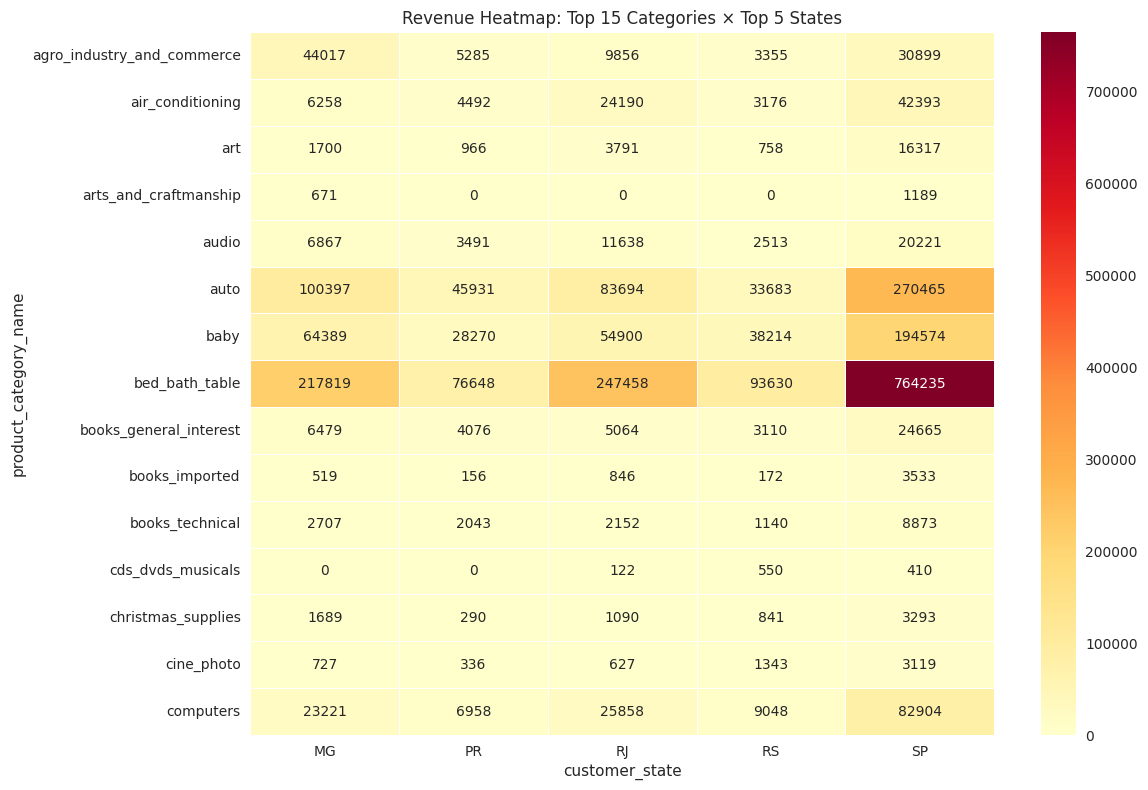


INSIGHT: São Paulo dominates all categories. Secondary stocking focus should be
MG and RJ for health_beauty and sports_leisure.



In [ ]:
# =============================================================================
# 16. STATE MARKET SHARE BY PRODUCT CATEGORY — Sunburst + Heatmap## 
# =============================================================================

# fct_sales.customer_id does NOT match stg_customers.customer_id directly
# Must bridge via int_orders_enriched: order_id → customer_id → stg_customers

df_int_orders_bridge = load_table('int_orders_enriched')[['order_id', 'customer_id']]
df_stg_cust_state = load_table('stg_customers')[['customer_id', 'customer_state']]

# Step 1: get customer_id that matches stg_customers via int_orders_enriched
df_order_to_state = df_int_orders_bridge.merge(
    df_stg_cust_state, on='customer_id', how='left'
)[['order_id', 'customer_state']]

# Step 2: merge product categories + revenue from fct_sales, then attach state
df_state_cat = df_products_cat.merge(
    df_fct[['order_id', 'total_payment_value']], on='order_id', how='left'
).merge(
    df_order_to_state, on='order_id', how='left'
)
df_state_cat['total_payment_value'] = df_state_cat['total_payment_value'].astype(float)

# Sanity check
print(f"df_state_cat shape: {df_state_cat.shape}")
print(f"Null customer_state: {df_state_cat['customer_state'].isna().sum()}")
print(f"Null total_payment_value: {df_state_cat['total_payment_value'].isna().sum()}")
display(df_state_cat.head(3))

top_states = (
    df_state_cat.groupby('customer_state')['total_payment_value']
    .sum().nlargest(5).index.tolist()
)
print(f"\nTop 5 states: {top_states}")

state_cat_revenue = (
    df_state_cat[df_state_cat['customer_state'].isin(top_states)]
    .groupby(['customer_state', 'product_category_name'])['total_payment_value']
    .sum().reset_index(name='total_revenue')
    .sort_values('total_revenue', ascending=False)
)

print(f"state_cat_revenue shape: {state_cat_revenue.shape}")
display(state_cat_revenue.head(10))

fig = px.sunburst(
    state_cat_revenue, path=['customer_state', 'product_category_name'],
    values='total_revenue',
    title='Dashboard: State Market Share by Product Category (Top 5 States)',
    color='total_revenue', color_continuous_scale='RdPu'
)
fig.update_layout(margin=dict(t=50, l=0, r=0, b=0))
fig.show()

pivot = state_cat_revenue.pivot_table(
    index='product_category_name', columns='customer_state',
    values='total_revenue', fill_value=0
).head(15)

print(f"\nPivot shape: {pivot.shape}")

if pivot.empty:
    print("Pivot still empty — paste the sanity check output above.")
else:
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
    plt.title('Revenue Heatmap: Top 15 Categories × Top 5 States')
    plt.tight_layout()
    plt.show()

print("""
INSIGHT: São Paulo dominates all categories. Secondary stocking focus should be
MG and RJ for health_beauty and sports_leisure.
""")

In [ ]:
# =============================================================================
# 17. CUSTOMER LOYALTY SEGMENTATION — Treemap + Revenue by Segment# 
# =============================================================================
# Segmentation already computed in int_customer_segments — use it directly

df_segments = load_table('int_customer_segments')[['customer_id', 'segment']]

segment_counts = (
    df_segments.groupby('segment').size()
    .reset_index(name='customer_count')
    .sort_values('customer_count', ascending=False)
)
segment_counts['pct'] = (
    segment_counts['customer_count'] / segment_counts['customer_count'].sum() * 100
).round(1)

print("Customer Segment Distribution:")
display(segment_counts)

fig = px.treemap(
    segment_counts, path=['segment'], values='customer_count',
    color='customer_count', color_continuous_scale='RdYlGn',
    title='Dashboard: Customer Loyalty Mix (RFV Segmentation)'
)
fig.update_traces(texttemplate='%{label}<br>%{value} (%{percentRoot:.1%})')
fig.show()

# Revenue by segment
df_seg_revenue = df_fct_with_payment.merge(df_segments, on='customer_id', how='left')
seg_revenue = (
    df_seg_revenue.groupby('segment')['total_order_payment']
    .sum().reset_index(name='total_revenue')
    .sort_values('total_revenue', ascending=False)
)

fig2 = px.bar(
    seg_revenue, x='segment', y='total_revenue',
    title='Dashboard: Revenue Contribution by Customer Segment',
    labels={'total_revenue': 'Revenue (R$)', 'segment': 'Segment'},
    color='segment'
)
fig2.show()

print("""
INSIGHT: Potential Loyalists and Loyal Customers form the largest base.
At Risk customers need win-back campaigns.
Champions are few but highest value — protect them with exclusive perks.
""")

Customer Segment Distribution:


,segment,customer_count,pct
5,Potential Loyalists,29731,31.4
0,At Risk - Cannot Lose Them,23325,24.6
3,Loyal Customers,22291,23.5
4,New Customers - Promising,11719,12.4
2,Hibernating - Lost,5900,6.2
1,Champions,1733,1.8



INSIGHT: Potential Loyalists and Loyal Customers form the largest base.
At Risk customers need win-back campaigns.
Champions are few but highest value — protect them with exclusive perks.

